In [8]:
import braid_analysis

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pandas as pd

from braid_analysis import braid_filemanager
from braid_analysis import braid_2d_analysis as b2d

# Data folder

In [15]:
data_folder = '/Users/florisvb/src/braid_2d_3d_data/20241211_double_flash'
window_s    = 5.0   # seconds before/after each trigger to load and analyse

# Load experiment config and trigger events

In [16]:
exp_code    = b2d.load_exp_code(data_folder)
df_triggers = b2d.load_triggers(data_folder, exp_code)

print(f'Triggers loaded: {len(df_triggers)}')
print('Trigger counts per stimulus condition:')
print(df_triggers.groupby(exp_code['column_names']).size().reset_index(name='count').to_string(index=False))

Triggers loaded: 291
Trigger counts per stimulus condition:
 first_flash_duration  second_flash_duration  number_of_flashes  intermittency  count
                  0.0                    0.0                0.0            0.0     37
                 25.0                    0.0                1.0            0.0     37
                 25.0                  200.0                2.0         2000.0     42
                 25.0                  200.0                2.0         6000.0     52
                200.0                    0.0                1.0            0.0     40
                200.0                  200.0                2.0         2000.0     37
                200.0                  200.0                2.0         6000.0     46


# Load 3D data and the 2D data windowed around triggers

In [17]:
braidz_filename = b2d.get_filename(data_folder, '.braidz')

# Full 3D data (fast to load)
df_3d = braid_filemanager.load_filename_as_dataframe_3d(braidz_filename)
print('3D data shape:', df_3d.shape)

3D data shape: (7576804, 18)


# obj_ids present at each trigger frame

In [18]:
# Get trigger frame numbers from data_2 column and map to unique obj_ids in df_3d
trigger_frames = df_triggers['data_2'].dropna().astype(int).unique()

frame_to_obj_ids = {}
for frame in trigger_frames:
    obj_ids = df_3d.loc[df_3d['frame'] == frame, 'obj_id'].unique().tolist()
    frame_to_obj_ids[frame] = obj_ids

print(f'Trigger frames queried: {len(frame_to_obj_ids)}')
print(f'Example (first 5):')
for frame, ids in list(frame_to_obj_ids.items())[:5]:
    print(f'  frame {frame}: {ids}')

Trigger frames queried: 291
Example (first 5):
  frame 264369: [118, 124]
  frame 274544: [242, 243]
  frame 365613: [555, 590, 591]
  frame 386118: [693, 694]
  frame 400808: [773, 774]


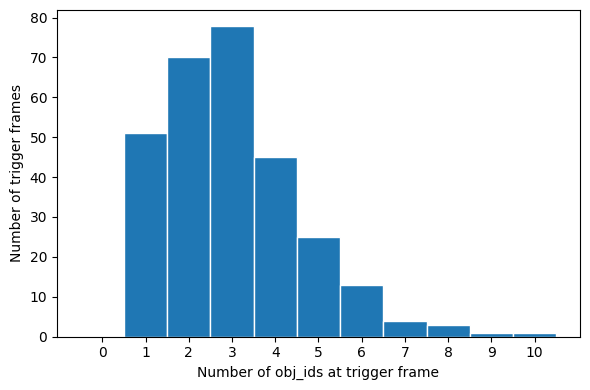

In [19]:
n_obj_ids = [len(ids) for ids in frame_to_obj_ids.values()]

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(n_obj_ids, bins=range(max(n_obj_ids) + 2), align='left', edgecolor='white')
ax.set_xlabel('Number of obj_ids at trigger frame')
ax.set_ylabel('Number of trigger frames')
ax.set_xticks(range(max(n_obj_ids) + 1))
plt.tight_layout()
plt.show()